In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


# Load corrected dataset
df = pd.read_csv(
    "../data/processed/ml_vehicle_group_demand.csv"
)

df["month"] = pd.to_datetime(df["month"])

df = df.sort_values("month").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["month"].min(), "to", df["month"].max())

Dataset shape: (10556, 16)
Date range: 2020-01-01 00:00:00 to 2024-04-01 00:00:00


In [48]:
features = [
    "state",
    "vehicle_group",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "monthly_growth",
    "yearly_growth",
    "year",
    "month_number",
    "quarter"
]

target = "target_demand"

In [49]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training rows:", len(train))
print("Testing rows :", len(test))

print(
    "Training period:",
    train["month"].min(),
    "to",
    train["month"].max()
)

print(
    "Testing period :",
    test["month"].min(),
    "to",
    test["month"].max()
)

TRAIN / TEST SPLIT
Training rows: 8444
Testing rows : 2112
Training period: 2020-01-01 00:00:00 to 2023-06-01 00:00:00
Testing period : 2023-06-01 00:00:00 to 2024-04-01 00:00:00


In [50]:
categorical_features = [
    "state",
    "vehicle_group"
]

numeric_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "monthly_growth",
    "yearly_growth",
    "year",
    "month_number",
    "quarter"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [52]:
# ============================================================
# CLEAN ML FEATURES BEFORE MODEL TRAINING
# ============================================================

# Replace infinite values with NaN
ml_df = ml_df.replace([np.inf, -np.inf], np.nan)

# Check missing values
print("Missing values before cleaning:")
print(ml_df[features].isnull().sum())

# Fill growth-related missing values with 0
ml_df["monthly_growth"] = ml_df["monthly_growth"].fillna(0)
ml_df["yearly_growth"] = ml_df["yearly_growth"].fillna(0)

# Final check
print("\nMissing values after cleaning:")
print(ml_df[features].isnull().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        ml_df[numeric_features].to_numpy()
    ).sum()
)

Missing values before cleaning:
state               0
vehicle_group       0
lag_1               0
lag_2               0
lag_3               0
lag_12              0
rolling_mean_3      0
rolling_mean_6      0
monthly_growth    644
yearly_growth     651
year                0
month_number        0
quarter             0
dtype: int64

Missing values after cleaning:
0

Infinite values:
0


In [53]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

ml_df = ml_df.sort_values("month").reset_index(drop=True)

split_index = int(len(ml_df) * 0.8)

train = ml_df.iloc[:split_index].copy()
test = ml_df.iloc[split_index:].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training rows:", len(train))
print("Testing rows:", len(test))

print(
    "Training period:",
    train["month"].min(),
    "to",
    train["month"].max()
)

print(
    "Testing period:",
    test["month"].min(),
    "to",
    test["month"].max()
)

Training rows: 8444
Testing rows: 2112
Training period: 2020-01-01 00:00:00 to 2023-06-01 00:00:00
Testing period: 2023-06-01 00:00:00 to 2024-04-01 00:00:00


In [54]:
categorical_features = [
    "state",
    "vehicle_group"
]

numeric_features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "monthly_growth",
    "yearly_growth",
    "year",
    "month_number",
    "quarter"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [55]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [56]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [57]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [58]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    ),

    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,24867.760975,78548.705714,0.737433
1,Random Forest,5107.893532,40480.660897,0.930264
2,XGBoost,5201.263149,37227.513032,0.941022


In [59]:
print("=" * 60)
print("PREDICTION RANGE CHECK")
print("=" * 60)

print(
    "Actual demand:",
    y_test.min(),
    "to",
    y_test.max()
)

print(
    "Linear Regression:",
    linear_pred.min(),
    "to",
    linear_pred.max()
)

print(
    "Random Forest:",
    rf_pred.min(),
    "to",
    rf_pred.max()
)

print(
    "XGBoost:",
    xgb_pred.min(),
    "to",
    xgb_pred.max()
)

PREDICTION RANGE CHECK
Actual demand: 0.0 to 2642873.0
Linear Regression: -440455.96512182796 to 1640561.0238697769
Random Forest: 4.486516486177603 to 1957208.8651348737
XGBoost: -7740.2495 to 1720703.9


In [60]:
# ============================================================
# TARGET ALIGNMENT CHECK
# ============================================================

check = ml_df[
    [
        "month",
        "state",
        "vehicle_group",
        "registrations",
        "target_demand"
    ]
].copy()

check["expected_target"] = (
    check
    .groupby(
        ["state", "vehicle_group"]
    )["registrations"]
    .shift(-1)
)

# Ignore final rows where there is no next month
valid_check = check[
    check["expected_target"].notna()
]

alignment_accuracy = (
    valid_check["target_demand"]
    == valid_check["expected_target"]
).mean() * 100

print(
    f"Target alignment accuracy: "
    f"{alignment_accuracy:.2f}%"
)

Target alignment accuracy: 100.00%


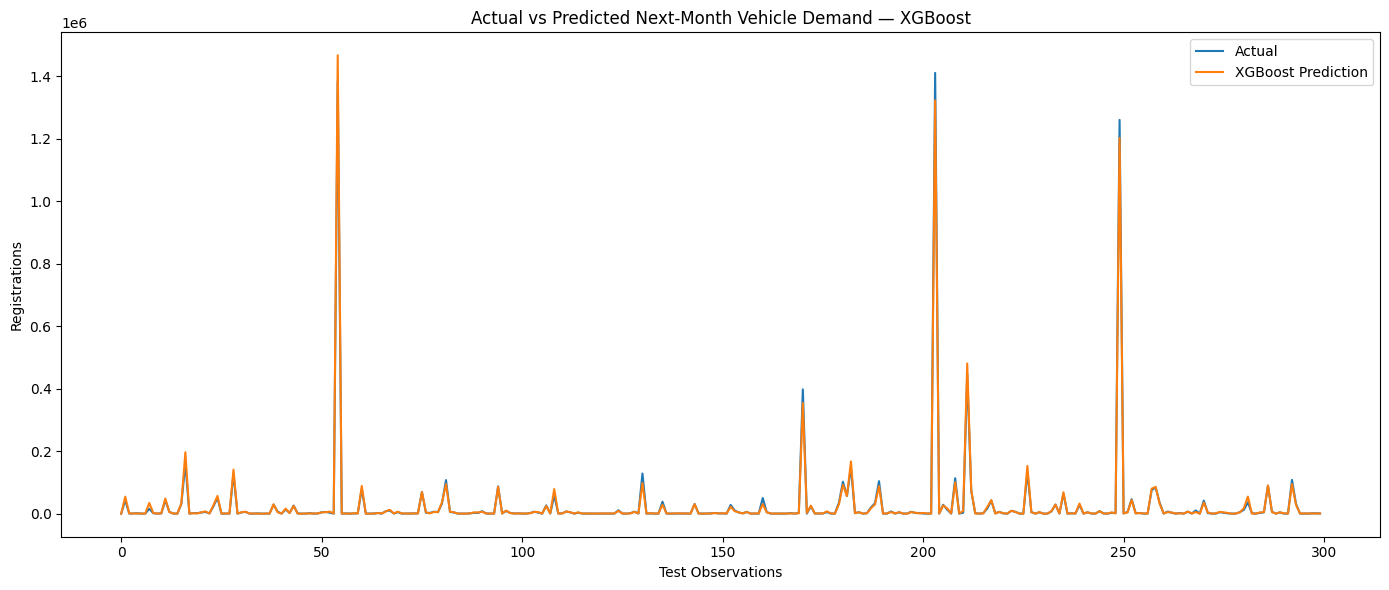

In [61]:
# ============================================================
# ACTUAL VS PREDICTED — XGBOOST
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:300],
    label="Actual"
)

plt.plot(
    xgb_pred[:300],
    label="XGBoost Prediction"
)

plt.title(
    "Actual vs Predicted Next-Month Vehicle Demand — XGBoost"
)

plt.xlabel("Test Observations")
plt.ylabel("Registrations")

plt.legend()

plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# XGBOOST ERROR ANALYSIS
# ============================================================

# Non-negative predictions for business interpretation
xgb_pred_final = np.maximum(xgb_pred, 0)

evaluation = test[
    [
        "month",
        "state",
        "vehicle_group",
        "registrations",
        "target_demand"
    ]
].copy()

evaluation["predicted_demand"] = xgb_pred_final

evaluation["absolute_error"] = (
    np.abs(
        evaluation["target_demand"]
        - evaluation["predicted_demand"]
    )
)

# Percentage error
evaluation["percentage_error"] = np.where(
    evaluation["target_demand"] > 0,
    (
        evaluation["absolute_error"]
        / evaluation["target_demand"]
    ) * 100,
    np.nan
)


# ------------------------------------------------------------
# TOP 20 LARGEST ERRORS
# ------------------------------------------------------------

largest_errors = (
    evaluation
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

print("=" * 70)
print("TOP 20 LARGEST XGBOOST PREDICTION ERRORS")
print("=" * 70)

display(largest_errors)


# ------------------------------------------------------------
# PERFORMANCE BY VEHICLE GROUP
# ------------------------------------------------------------

group_performance = (
    evaluation
    .groupby("vehicle_group")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=(
            "absolute_error",
            lambda x: np.sqrt(np.mean(x ** 2))
        ),
        Actual_Average=(
            "target_demand",
            "mean"
        ),
        Predicted_Average=(
            "predicted_demand",
            "mean"
        ),
        Observations=(
            "target_demand",
            "count"
        )
    )
    .sort_values("MAE")
)

print("\n" + "=" * 70)
print("PERFORMANCE BY VEHICLE GROUP")
print("=" * 70)

display(group_performance)

TOP 20 LARGEST XGBOOST PREDICTION ERRORS


,month,state,vehicle_group,registrations,target_demand,predicted_demand,absolute_error,percentage_error
9147,2023-10-01,Rajasthan,Two Wheeler,1720282.0,2642873.0,1.720704e+06,922169.125000,34.892676
9674,2023-12-01,Arunachal Pradesh,Two Wheeler,1455451.0,991.0,8.413053e+05,840314.312500,84794.582492
9617,2023-12-01,Rajasthan,Two Wheeler,1653619.0,1621864.0,1.024074e+06,597790.500000,36.858238
9205,2023-10-01,Arunachal Pradesh,Two Wheeler,1515816.0,2260208.0,1.719488e+06,540719.750000,23.923451
10221,2024-03-01,Rajasthan,Two Wheeler,1713349.0,1815536.0,1.356120e+06,459415.500000,25.304676
9558,2023-12-01,Arunachal Pradesh,Passenger Vehicle,376994.0,1183.0,3.462462e+05,345063.218750,29168.488483
9321,2023-10-01,Uttar Pradesh,Two Wheeler,165540.0,392892.0,1.798846e+05,213007.421875,54.215261
10404,2024-04-01,Rajasthan,Two Wheeler,1815536.0,1712630.0,1.514345e+06,198284.875000,11.577800
8931,2023-08-01,Rajasthan,Two Wheeler,1410907.0,1477757.0,1.305721e+06,172036.125000,11.641706
8986,2023-09-01,Arunachal Pradesh,Two Wheeler,1317501.0,1515816.0,1.649880e+06,134064.125000,8.844353



PERFORMANCE BY VEHICLE GROUP


,MAE,RMSE,Actual_Average,Predicted_Average,Observations
vehicle_group,,,,,
Other Motor Vehicle,287.112797,868.330412,102.441926,361.844208,353
Passenger Transport,362.013248,885.731120,353.949153,628.654297,354
Goods Vehicle,1596.291851,7564.503097,6059.186441,6903.190918,354
Three Wheeler,1820.301309,6641.387686,7930.872464,8294.303711,345
Passenger Vehicle,4550.586234,21464.243659,30431.788571,31758.326172,350
Two Wheeler,22162.900295,87559.545383,116821.755618,110777.312500,356


In [63]:
# ============================================================
# DEMAND SPIKE DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest

# Work on a copy
anomaly_df = ml_df.copy()

# Calculate demand change
anomaly_df["demand_change"] = (
    anomaly_df["registrations"]
    - anomaly_df["lag_1"]
)

# Calculate percentage change safely
anomaly_df["demand_change_pct"] = np.where(
    anomaly_df["lag_1"] > 0,
    (
        anomaly_df["demand_change"]
        / anomaly_df["lag_1"]
    ) * 100,
    0
)

# Features for anomaly detection
anomaly_features = [
    "registrations",
    "lag_1",
    "lag_2",
    "rolling_mean_3",
    "rolling_mean_6",
    "demand_change_pct"
]

# Clean infinite / missing values
X_anomaly = (
    anomaly_df[anomaly_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ============================================================
# ISOLATION FOREST
# ============================================================

isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_df["anomaly_prediction"] = (
    isolation_model.fit_predict(X_anomaly)
)

anomaly_df["anomaly_score"] = (
    isolation_model.decision_function(X_anomaly)
)

# -1 = anomaly
#  1 = normal

anomaly_df["is_anomaly"] = (
    anomaly_df["anomaly_prediction"] == -1
)

print("=" * 70)
print("DEMAND ANOMALY DETECTION")
print("=" * 70)

print(
    "Total observations:",
    len(anomaly_df)
)

print(
    "Anomalies detected:",
    anomaly_df["is_anomaly"].sum()
)

print(
    "Normal observations:",
    (~anomaly_df["is_anomaly"]).sum()
)

DEMAND ANOMALY DETECTION
Total observations: 10556
Anomalies detected: 528
Normal observations: 10028


In [64]:
# ============================================================
# TOP DEMAND SPIKES
# ============================================================

spikes = (
    anomaly_df[
        anomaly_df["is_anomaly"]
    ]
    .sort_values(
        "demand_change_pct",
        ascending=False
    )
)

print("=" * 70)
print("TOP 30 DEMAND SPIKES")
print("=" * 70)

display(
    spikes[
        [
            "month",
            "state",
            "vehicle_group",
            "registrations",
            "lag_1",
            "demand_change_pct",
            "anomaly_score"
        ]
    ].head(30)
)

TOP 30 DEMAND SPIKES


,month,state,vehicle_group,registrations,lag_1,demand_change_pct,anomaly_score
183,2020-01-01,Himachal Pradesh,Three Wheeler,71714.0,21.0,341395.238095,-0.062425
893,2020-05-01,Manipur,Three Wheeler,2214.0,1.0,221300.000000,-0.018759
73,2020-01-01,Arunachal Pradesh,Three Wheeler,71725.0,44.0,162911.363636,-0.058712
3499,2021-06-01,Delhi,Two Wheeler,22182.0,23.0,96343.478261,-0.046752
54,2020-01-01,Arunachal Pradesh,Goods Vehicle,82981.0,125.0,66284.800000,-0.053101
920,2020-05-01,Manipur,Two Wheeler,193019.0,319.0,60407.523511,-0.069469
836,2020-05-01,Manipur,Passenger Vehicle,44388.0,77.0,57546.753247,-0.033324
71,2020-01-01,Arunachal Pradesh,Passenger Vehicle,380528.0,667.0,56950.674663,-0.083515
3496,2021-06-01,Delhi,Passenger Vehicle,12929.0,23.0,56113.043478,-0.034090
3356,2021-05-01,Mizoram,Passenger Vehicle,111140.0,280.0,39592.857143,-0.049924


In [65]:
# ============================================================
# IMPROVED DEMAND SPIKE DETECTION
# ============================================================

spike_df = ml_df.copy()

group_cols = ["state", "vehicle_group"]

# Historical 3-month average
spike_df["baseline_3m"] = (
    spike_df
    .groupby(group_cols)["registrations"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

# Historical 6-month average
spike_df["baseline_6m"] = (
    spike_df
    .groupby(group_cols)["registrations"]
    .transform(
        lambda x: x.shift(1).rolling(6).mean()
    )
)

# Difference from 3-month baseline
spike_df["baseline_change_pct"] = np.where(
    spike_df["baseline_3m"] > 0,
    (
        (
            spike_df["registrations"]
            - spike_df["baseline_3m"]
        )
        / spike_df["baseline_3m"]
    ) * 100,
    np.nan
)

# Ratio against baseline
spike_df["demand_ratio"] = np.where(
    spike_df["baseline_3m"] > 0,
    spike_df["registrations"]
    / spike_df["baseline_3m"],
    np.nan
)

print("Spike analysis dataset:", spike_df.shape)

Spike analysis dataset: (10556, 20)


In [66]:
# ============================================================
# SIGNIFICANT DEMAND SPIKES
# ============================================================

significant_spikes = spike_df[
    (spike_df["demand_ratio"] >= 2) &
    (spike_df["registrations"] > spike_df["baseline_3m"])
].copy()

significant_spikes = significant_spikes.sort_values(
    "demand_ratio",
    ascending=False
)

print("=" * 70)
print("SIGNIFICANT DEMAND SPIKES")
print("=" * 70)

print(
    "Number of significant spikes:",
    len(significant_spikes)
)

display(
    significant_spikes[
        [
            "month",
            "state",
            "vehicle_group",
            "registrations",
            "baseline_3m",
            "demand_ratio",
            "baseline_change_pct"
        ]
    ].head(30)
)

SIGNIFICANT DEMAND SPIKES
Number of significant spikes: 743


,month,state,vehicle_group,registrations,baseline_3m,demand_ratio,baseline_change_pct
3376,2021-05-01,Mizoram,Passenger Transport,487.0,0.333333,1461.000000,146000.000000
3356,2021-05-01,Mizoram,Passenger Vehicle,111140.0,404.666667,274.645799,27364.579901
3430,2021-05-01,Mizoram,Other Motor Vehicle,599.0,2.333333,256.714286,25571.428571
3373,2021-05-01,Mizoram,Two Wheeler,459443.0,2079.333333,220.956877,21995.687720
920,2020-05-01,Manipur,Two Wheeler,193019.0,1648.000000,117.123180,11612.317961
10039,2024-02-01,Meghalaya,Other Motor Vehicle,32.0,0.333333,96.000000,9500.000000
3385,2021-05-01,Mizoram,Three Wheeler,5828.0,64.666667,90.123711,8912.371134
836,2020-05-01,Manipur,Passenger Vehicle,44388.0,608.666667,72.926616,7192.661555
3445,2021-05-01,Mizoram,Goods Vehicle,19019.0,263.666667,72.132743,7113.274336
1628,2020-09-01,Ladakh,Goods Vehicle,24.0,0.333333,72.000000,7100.000000


In [67]:
# ============================================================
# SUPPLY CHAIN ALERT LEVEL
# ============================================================

spike_df["alert_level"] = "Normal"

spike_df.loc[
    spike_df["demand_ratio"] >= 1.5,
    "alert_level"
] = "Watch"

spike_df.loc[
    spike_df["demand_ratio"] >= 2,
    "alert_level"
] = "High"

spike_df.loc[
    spike_df["demand_ratio"] >= 3,
    "alert_level"
] = "Critical"

print(
    spike_df["alert_level"].value_counts()
)

alert_level
Normal      9015
Watch        798
High         386
Critical     357
Name: count, dtype: int64


In [68]:
# ============================================================
# SUPPLY CHAIN ALERT TABLE
# ============================================================

alerts = (
    spike_df[
        spike_df["alert_level"] != "Normal"
    ]
    .sort_values(
        "demand_ratio",
        ascending=False
    )
)

display(
    alerts[
        [
            "month",
            "state",
            "vehicle_group",
            "registrations",
            "baseline_3m",
            "demand_ratio",
            "baseline_change_pct",
            "alert_level"
        ]
    ].head(50)
)

,month,state,vehicle_group,registrations,baseline_3m,demand_ratio,baseline_change_pct,alert_level
3376,2021-05-01,Mizoram,Passenger Transport,487.0,0.333333,1461.000000,146000.000000,Critical
3356,2021-05-01,Mizoram,Passenger Vehicle,111140.0,404.666667,274.645799,27364.579901,Critical
3430,2021-05-01,Mizoram,Other Motor Vehicle,599.0,2.333333,256.714286,25571.428571,Critical
3373,2021-05-01,Mizoram,Two Wheeler,459443.0,2079.333333,220.956877,21995.687720,Critical
920,2020-05-01,Manipur,Two Wheeler,193019.0,1648.000000,117.123180,11612.317961,Critical
10039,2024-02-01,Meghalaya,Other Motor Vehicle,32.0,0.333333,96.000000,9500.000000,Critical
3385,2021-05-01,Mizoram,Three Wheeler,5828.0,64.666667,90.123711,8912.371134,Critical
836,2020-05-01,Manipur,Passenger Vehicle,44388.0,608.666667,72.926616,7192.661555,Critical
3445,2021-05-01,Mizoram,Goods Vehicle,19019.0,263.666667,72.132743,7113.274336,Critical
1628,2020-09-01,Ladakh,Goods Vehicle,24.0,0.333333,72.000000,7100.000000,Critical


In [72]:
# Generate XGBoost predictions again
xgb_pred = xgb_model.predict(X_test)

# Prevent negative demand predictions
xgb_pred = np.maximum(xgb_pred, 0)

print("Corrected XGBoost prediction range:")
print("Minimum:", xgb_pred.min())
print("Maximum:", xgb_pred.max())

Corrected XGBoost prediction range:
Minimum: 0.0
Maximum: 1720703.9


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("===== CORRECTED XGBOOST RESULTS =====")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

===== CORRECTED XGBOOST RESULTS =====
MAE : 5163.490748447676
RMSE: 37225.0233409837
R²  : 0.9410299645251836


In [74]:
# Final model comparison with corrected XGBoost

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        24867.760975,
        5107.893532,
        xgb_mae
    ],
    "RMSE": [
        78548.705714,
        40480.660897,
        xgb_rmse
    ],
    "R2": [
        0.737433,
        0.930264,
        xgb_r2
    ]
})

display(final_results)

,Model,MAE,RMSE,R2
0,Linear Regression,24867.760975,78548.705714,0.737433
1,Random Forest,5107.893532,40480.660897,0.930264
2,XGBoost,5163.490748,37225.023341,0.941030


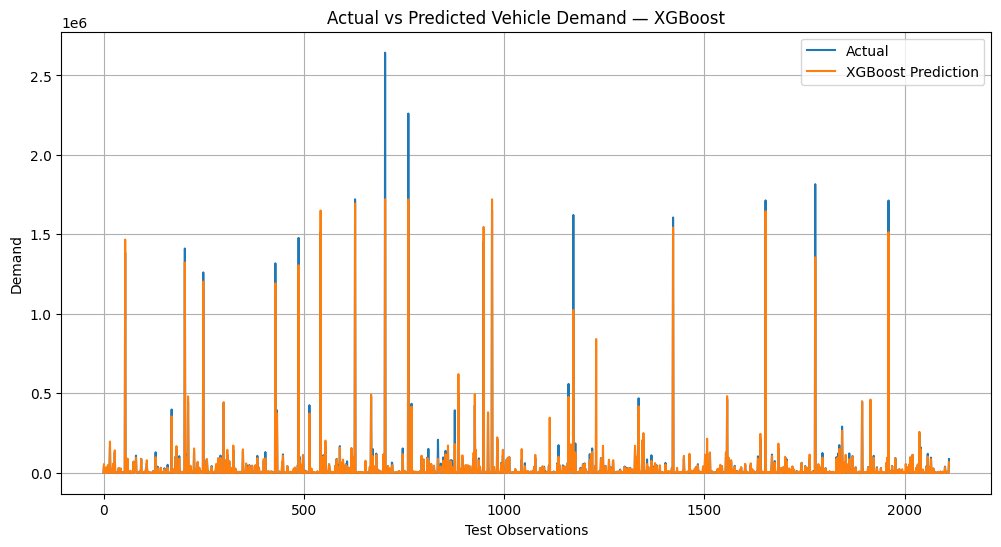

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    label="Actual"
)

plt.plot(
    range(len(xgb_pred)),
    xgb_pred,
    label="XGBoost Prediction"
)

plt.title("Actual vs Predicted Vehicle Demand — XGBoost")
plt.xlabel("Test Observations")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
# ============================================================
# FINAL BUSINESS INSIGHTS DATASET
# ============================================================

# Use XGBoost predictions
predicted_demand = xgb_pred.copy()

# Remove negative predictions
predicted_demand = np.maximum(predicted_demand, 0)

# Create results dataset
results_df = X_test.copy()

results_df["actual_demand"] = y_test.values
results_df["predicted_demand"] = predicted_demand

# Calculate absolute error
results_df["absolute_error"] = np.abs(
    results_df["actual_demand"] - results_df["predicted_demand"]
)

# Calculate percentage error
results_df["error_pct"] = np.where(
    results_df["actual_demand"] != 0,
    (results_df["absolute_error"] / results_df["actual_demand"]) * 100,
    0
)

print("Final results dataset shape:", results_df.shape)

display(results_df.head())

Final results dataset shape: (2112, 17)


,state,vehicle_group,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6,monthly_growth,yearly_growth,year,month_number,quarter,actual_demand,predicted_demand,absolute_error,error_pct
8444,Delhi,Other Motor Vehicle,1.0,0.0,0.0,0.0,0.333333,0.166667,-1.000000,0.000000,2023,6,2,0.0,0.000000,0.000000,0.000000
8445,Uttar Pradesh,Passenger Vehicle,46667.0,42475.0,46670.0,38946.0,45270.666667,45271.500000,0.023507,0.226416,2023,6,2,42868.0,54221.296875,11353.296875,26.484317
8446,Nagaland,Passenger Transport,42.0,55.0,52.0,22.0,49.666667,45.000000,0.142857,1.181818,2023,6,2,35.0,517.996521,482.996521,1379.990060
8447,Uttarakhand,Goods Vehicle,666.0,582.0,631.0,555.0,626.333333,594.500000,-0.088589,0.093694,2023,6,2,572.0,316.620453,255.379547,44.646774
8448,Chhattisgarh,Three Wheeler,968.0,844.0,963.0,533.0,925.000000,858.833333,0.084711,0.969981,2023,6,2,1152.0,685.544800,466.455200,40.490903


In [78]:
# ============================================================
# STATE-WISE DEMAND INSIGHTS
# ============================================================

state_insights = (
    results_df
    .groupby("state")
    .agg(
        actual_demand=("actual_demand", "sum"),
        predicted_demand=("predicted_demand", "sum"),
        average_error=("absolute_error", "mean"),
        observations=("actual_demand", "count")
    )
    .sort_values("actual_demand", ascending=False)
)

state_insights["prediction_difference"] = (
    state_insights["predicted_demand"]
    - state_insights["actual_demand"]
)

print("===== TOP 15 STATES BY ACTUAL DEMAND =====")

display(
    state_insights.head(15)
)

===== TOP 15 STATES BY ACTUAL DEMAND =====


,actual_demand,predicted_demand,average_error,observations,prediction_difference
state,,,,,
Rajasthan,25691410.0,2.357921e+07,54545.452426,64,-2.112202e+06
Arunachal Pradesh,10797786.0,1.202050e+07,48855.423072,62,1.222715e+06
Uttar Pradesh,3264311.0,3.165331e+06,9258.795204,64,-9.898000e+04
Maharashtra,2504001.0,2.421225e+06,5766.097521,64,-8.277625e+04
Tamil Nadu,1628569.0,1.865767e+06,7689.312945,63,2.371979e+05
Gujarat,1601989.0,1.525025e+06,5047.322560,61,-7.696425e+04
Karnataka,1571155.0,1.454002e+06,3217.799929,63,-1.171528e+05
Madhya Pradesh,1372693.0,1.363238e+06,6453.421592,61,-9.455125e+03
Bihar,1203265.0,1.109792e+06,4236.544279,63,-9.347325e+04


In [79]:
# ============================================================
# VEHICLE-GROUP DEMAND INSIGHTS
# ============================================================

vehicle_insights = (
    results_df
    .groupby("vehicle_group")
    .agg(
        actual_demand=("actual_demand", "sum"),
        predicted_demand=("predicted_demand", "sum"),
        average_error=("absolute_error", "mean"),
        observations=("actual_demand", "count")
    )
    .sort_values("actual_demand", ascending=False)
)

vehicle_insights["prediction_difference"] = (
    vehicle_insights["predicted_demand"]
    - vehicle_insights["actual_demand"]
)

print("===== VEHICLE-GROUP DEMAND INSIGHTS =====")

display(vehicle_insights)

===== VEHICLE-GROUP DEMAND INSIGHTS =====


,actual_demand,predicted_demand,average_error,observations,prediction_difference
vehicle_group,,,,,
Two Wheeler,41588545.0,3.943672e+07,22162.900295,356,-2.151821e+06
Passenger Vehicle,10651126.0,1.111541e+07,4550.586234,350,4.642880e+05
Three Wheeler,2736151.0,2.861535e+06,1820.301309,345,1.253838e+05
Goods Vehicle,2144952.0,2.443730e+06,1596.291851,354,2.987775e+05
Passenger Transport,125298.0,2.225436e+05,362.013248,354,9.724562e+04
Other Motor Vehicle,36162.0,1.277310e+05,287.112797,353,9.156901e+04


In [80]:
import joblib
import os

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save trained XGBoost model
joblib.dump(xgb_model, "../models/xgboost_demand_model.pkl")

print("✅ XGBoost model saved successfully!")
print("📁 Location: models/xgboost_demand_model.pkl")

✅ XGBoost model saved successfully!
📁 Location: models/xgboost_demand_model.pkl


In [81]:
# ============================================================
# STEP 6: CHECK XGBOOST MODEL FEATURES
# ============================================================

print("XGBoost model feature count:",
      xgb_model.n_features_in_)

print("\nFeatures used by XGBoost:")
for i, feature in enumerate(xgb_model.feature_names_in_, 1):
    print(f"{i}. {feature}")

XGBoost model feature count: 13

Features used by XGBoost:
1. state
2. vehicle_group
3. lag_1
4. lag_2
5. lag_3
6. lag_12
7. rolling_mean_3
8. rolling_mean_6
9. monthly_growth
10. yearly_growth
11. year
12. month_number
13. quarter


In [82]:
# ============================================================
# STEP 7: FUTURE DEMAND FORECASTING
# ============================================================

import pandas as pd
import numpy as np

# Number of months to forecast
FORECAST_MONTHS = 6

# Work from the cleaned ML dataset
history = ml_df.copy()

history["month"] = pd.to_datetime(history["month"])

# Make sure data is sorted
history = history.sort_values(
    ["state", "vehicle_group", "month"]
).reset_index(drop=True)

# Get the last available month
last_month = history["month"].max()

future_dates = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq="MS"
)

print("Historical data ends:", last_month)
print("Forecast months:")
for d in future_dates:
    print(" ", d.strftime("%Y-%m-%d"))

print("\nNumber of state × vehicle groups:",
      history[["state", "vehicle_group"]].drop_duplicates().shape[0])

Historical data ends: 2024-04-01 00:00:00
Forecast months:
  2024-05-01
  2024-06-01
  2024-07-01
  2024-08-01
  2024-09-01
  2024-10-01

Number of state × vehicle groups: 203


In [84]:
# ============================================================
# FUTURE DEMAND FORECASTING — XGBOOST
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("XGBOOST FUTURE DEMAND FORECAST")
print("=" * 70)

# ------------------------------------------------------------
# 1. COPY HISTORICAL DATA
# ------------------------------------------------------------

forecast_df = ml_df.copy()

forecast_df["month"] = pd.to_datetime(forecast_df["month"])

# Make sure data is sorted
forecast_df = forecast_df.sort_values(
    ["state", "vehicle_group", "month"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. HISTORICAL END DATE
# ------------------------------------------------------------

historical_end = forecast_df["month"].max()

forecast_months = pd.date_range(
    start=historical_end + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

print("Historical data ends:", historical_end)
print("Forecast months:", forecast_months)
print(
    "Number of state × vehicle groups:",
    forecast_df[["state", "vehicle_group"]].drop_duplicates().shape[0]
)

# ------------------------------------------------------------
# 3. IDENTIFY XGBOOST FEATURES
# ------------------------------------------------------------

feature_columns = [
    "state",
    "vehicle_group",
    "registrations",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "monthly_growth",
    "yearly_growth",
    "year",
    "month_number",
    "quarter"
]

# Keep only columns that actually exist
feature_columns = [
    col for col in feature_columns
    if col in forecast_df.columns
]

print("\nFeatures used:")
print(feature_columns)

# ------------------------------------------------------------
# 4. GET ALL STATE × VEHICLE GROUP COMBINATIONS
# ------------------------------------------------------------

groups = (
    forecast_df[["state", "vehicle_group"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nTotal groups:", len(groups))

# ------------------------------------------------------------
# 5. CREATE FORECAST STORAGE
# ------------------------------------------------------------

forecast_results = []

# ------------------------------------------------------------
# 6. FORECAST MONTH BY MONTH
# ------------------------------------------------------------

for forecast_month in forecast_months:

    print(f"\nForecasting: {forecast_month.strftime('%Y-%m')}")

    for _, group in groups.iterrows():

        state = group["state"]
        vehicle_group = group["vehicle_group"]

        # ----------------------------------------------------
        # GET HISTORY FOR THIS STATE + VEHICLE GROUP
        # ----------------------------------------------------

        history = forecast_df[
            (forecast_df["state"] == state) &
            (forecast_df["vehicle_group"] == vehicle_group)
        ].sort_values("month").copy()

        if len(history) == 0:
            continue

        # ----------------------------------------------------
        # DEMAND HISTORY
        # ----------------------------------------------------

        demand_history = history["target_demand"].astype(float).tolist()

        # Registration history
        registration_history = (
            history["registrations"]
            .astype(float)
            .tolist()
        )

        # ----------------------------------------------------
        # LAGS
        # ----------------------------------------------------

        lag_1 = demand_history[-1] if len(demand_history) >= 1 else 0.0

        lag_2 = demand_history[-2] if len(demand_history) >= 2 else lag_1

        lag_3 = demand_history[-3] if len(demand_history) >= 3 else lag_2

        lag_12 = (
            demand_history[-12]
            if len(demand_history) >= 12
            else lag_1
        )

        # ----------------------------------------------------
        # ROLLING MEANS
        # ----------------------------------------------------

        rolling_mean_3 = (
            np.mean(demand_history[-3:])
            if len(demand_history) >= 3
            else np.mean(demand_history)
        )

        rolling_mean_6 = (
            np.mean(demand_history[-6:])
            if len(demand_history) >= 6
            else np.mean(demand_history)
        )

        # ----------------------------------------------------
        # GROWTH FEATURES
        # ----------------------------------------------------

        if lag_1 != 0:
            monthly_growth = (
                (lag_1 - lag_2) / lag_2
                if lag_2 != 0
                else 0.0
            )
        else:
            monthly_growth = 0.0

        if lag_12 != 0:
            yearly_growth = (
                (lag_1 - lag_12) / lag_12
            )
        else:
            yearly_growth = 0.0

        # ----------------------------------------------------
        # REGISTRATION
        # ----------------------------------------------------

        registrations = (
            registration_history[-1]
            if len(registration_history) > 0
            else 0.0
        )

        # ----------------------------------------------------
        # DATE FEATURES
        # ----------------------------------------------------

        year = forecast_month.year

        month_number = forecast_month.month

        quarter = forecast_month.quarter

        # ----------------------------------------------------
        # BUILD FEATURE ROW
        # ----------------------------------------------------

        feature_row = pd.DataFrame({
            "state": [state],
            "vehicle_group": [vehicle_group],
            "registrations": [registrations],
            "lag_1": [lag_1],
            "lag_2": [lag_2],
            "lag_3": [lag_3],
            "lag_12": [lag_12],
            "rolling_mean_3": [rolling_mean_3],
            "rolling_mean_6": [rolling_mean_6],
            "monthly_growth": [monthly_growth],
            "yearly_growth": [yearly_growth],
            "year": [year],
            "month_number": [month_number],
            "quarter": [quarter]
        })

        # ----------------------------------------------------
        # ENSURE SAME COLUMN ORDER
        # ----------------------------------------------------

        feature_row = feature_row[feature_columns]

        # ----------------------------------------------------
        # HANDLE CATEGORICAL VARIABLES
        #
        # If your trained XGBoost model expects pandas
        # categorical columns, preserve them.
        # Otherwise use the same encoding objects from training.
        # ----------------------------------------------------

        for col in feature_row.columns:

            if col in ["state", "vehicle_group"]:

                feature_row[col] = feature_row[col].astype(str)

            else:

                feature_row[col] = pd.to_numeric(
                    feature_row[col],
                    errors="coerce"
                )

        # ----------------------------------------------------
        # FIX NaN / INF
        # ----------------------------------------------------

        feature_row = feature_row.replace(
            [np.inf, -np.inf],
            np.nan
        )

        feature_row = feature_row.fillna(0)

        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        prediction = xgb_model.predict(feature_row)[0]

        # IMPORTANT:
        # Convert numpy/string/object prediction to float
        # before applying max().
        # ----------------------------------------------------

        prediction = float(prediction)

        # Demand cannot be negative
        prediction = max(0.0, prediction)

        # ----------------------------------------------------
        # STORE RESULT
        # ----------------------------------------------------

        forecast_results.append({
            "month": forecast_month,
            "state": state,
            "vehicle_group": vehicle_group,
            "predicted_demand": prediction
        })

# ------------------------------------------------------------
# 7. CREATE FORECAST DATAFRAME
# ------------------------------------------------------------

forecast_results = pd.DataFrame(forecast_results)

# ------------------------------------------------------------
# 8. SORT RESULTS
# ------------------------------------------------------------

forecast_results = forecast_results.sort_values(
    ["month", "state", "vehicle_group"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. FINAL VALIDATION
# ------------------------------------------------------------

forecast_results["predicted_demand"] = pd.to_numeric(
    forecast_results["predicted_demand"],
    errors="coerce"
)

forecast_results["predicted_demand"] = (
    forecast_results["predicted_demand"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(lower=0)
)

print("\n" + "=" * 70)
print("FORECAST COMPLETED")
print("=" * 70)

print(
    "Forecast rows:",
    len(forecast_results)
)

print(
    "Forecast groups:",
    forecast_results[
        ["state", "vehicle_group"]
    ].drop_duplicates().shape[0]
)

print(
    "Forecast months:",
    forecast_results["month"].nunique()
)

print(
    "Minimum prediction:",
    forecast_results["predicted_demand"].min()
)

print(
    "Maximum prediction:",
    forecast_results["predicted_demand"].max()
)

print("\nFirst 20 predictions:")
display(forecast_results.head(20))

print("\nForecast summary:")
display(
    forecast_results.groupby("month")["predicted_demand"]
    .agg(["count", "sum", "mean", "min", "max"])
)

# ------------------------------------------------------------
# 10. SAVE FORECAST
# ------------------------------------------------------------

forecast_results.to_csv(
    "xgboost_demand_forecast.csv",
    index=False
)

print("\nSaved successfully:")
print("xgboost_demand_forecast.csv")

XGBOOST FUTURE DEMAND FORECAST
Historical data ends: 2024-04-01 00:00:00
Forecast months: DatetimeIndex(['2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01'],
              dtype='datetime64[ns]', freq='MS')
Number of state × vehicle groups: 203

Features used:
['state', 'vehicle_group', 'registrations', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'monthly_growth', 'yearly_growth', 'year', 'month_number', 'quarter']

Total groups: 203

Forecasting: 2024-05

Forecasting: 2024-06

Forecasting: 2024-07

Forecasting: 2024-08

Forecasting: 2024-09

Forecasting: 2024-10

FORECAST COMPLETED
Forecast rows: 1218
Forecast groups: 203
Forecast months: 6
Minimum prediction: 0.0
Maximum prediction: 1774344.125

First 20 predictions:


,month,state,vehicle_group,predicted_demand
0,2024-05-01,Andaman And Nicobar Islands,Goods Vehicle,369.934143
1,2024-05-01,Andaman And Nicobar Islands,Other Motor Vehicle,93.607948
2,2024-05-01,Andaman And Nicobar Islands,Passenger Transport,1152.336426
3,2024-05-01,Andaman And Nicobar Islands,Passenger Vehicle,369.934143
4,2024-05-01,Andaman And Nicobar Islands,Three Wheeler,0.000000
5,2024-05-01,Andaman And Nicobar Islands,Two Wheeler,1178.827637
6,2024-05-01,Andhra Pradesh,Goods Vehicle,2712.023438
7,2024-05-01,Andhra Pradesh,Other Motor Vehicle,1406.767944
8,2024-05-01,Andhra Pradesh,Passenger Transport,1406.767944
9,2024-05-01,Andhra Pradesh,Passenger Vehicle,8942.592773



Forecast summary:


,count,sum,mean,min,max
month,,,,,
2024-05-01,203,4.259327e+06,20981.906876,0.0,1525189.125
2024-06-01,203,4.298735e+06,21176.034662,0.0,1503822.750
2024-07-01,203,4.285073e+06,21108.735228,0.0,1478598.125
2024-08-01,203,4.216832e+06,20772.571378,0.0,1433023.125
2024-09-01,203,4.818793e+06,23737.895844,0.0,1751170.250
2024-10-01,203,4.881743e+06,24047.994031,0.0,1774344.125



Saved successfully:
xgboost_demand_forecast.csv


In [85]:
# ============================================================
# FORECAST SUMMARY
# ============================================================

print("=" * 70)
print("FORECAST SUMMARY")
print("=" * 70)

print("\nForecast shape:")
print(forecast_results.shape)

print("\nForecast date range:")
print(
    forecast_results["month"].min(),
    "to",
    forecast_results["month"].max()
)

print("\nForecast rows:")
print(len(forecast_results))

print("\nUnique states:")
print(forecast_results["state"].nunique())

print("\nUnique vehicle groups:")
print(forecast_results["vehicle_group"].nunique())

# ------------------------------------------------------------
# MONTHLY TOTAL FORECAST
# ------------------------------------------------------------

monthly_forecast = (
    forecast_results
    .groupby("month", as_index=False)["predicted_demand"]
    .sum()
)

print("\n" + "=" * 70)
print("MONTHLY TOTAL DEMAND FORECAST")
print("=" * 70)

display(monthly_forecast)

# ------------------------------------------------------------
# VEHICLE GROUP FORECAST
# ------------------------------------------------------------

vehicle_forecast = (
    forecast_results
    .groupby("vehicle_group", as_index=False)["predicted_demand"]
    .sum()
    .sort_values("predicted_demand", ascending=False)
)

print("\n" + "=" * 70)
print("VEHICLE GROUP FORECAST")
print("=" * 70)

display(vehicle_forecast)

# ------------------------------------------------------------
# STATE FORECAST
# ------------------------------------------------------------

state_forecast = (
    forecast_results
    .groupby("state", as_index=False)["predicted_demand"]
    .sum()
    .sort_values("predicted_demand", ascending=False)
)

print("\n" + "=" * 70)
print("TOP 20 STATES BY FORECASTED DEMAND")
print("=" * 70)

display(state_forecast.head(20))

# ------------------------------------------------------------
# SAVE SUMMARY FILES
# ------------------------------------------------------------

monthly_forecast.to_csv(
    "monthly_demand_forecast.csv",
    index=False
)

vehicle_forecast.to_csv(
    "vehicle_group_demand_forecast.csv",
    index=False
)

state_forecast.to_csv(
    "state_demand_forecast.csv",
    index=False
)

print("\nSummary files saved successfully!")

FORECAST SUMMARY

Forecast shape:
(1218, 4)

Forecast date range:
2024-05-01 00:00:00 to 2024-10-01 00:00:00

Forecast rows:
1218

Unique states:
34

Unique vehicle groups:
6

MONTHLY TOTAL DEMAND FORECAST


,month,predicted_demand
0,2024-05-01,4.259327e+06
1,2024-06-01,4.298735e+06
2,2024-07-01,4.285073e+06
3,2024-08-01,4.216832e+06
4,2024-09-01,4.818793e+06
5,2024-10-01,4.881743e+06



VEHICLE GROUP FORECAST


,vehicle_group,predicted_demand
5,Two Wheeler,1.927645e+07
3,Passenger Vehicle,4.909632e+06
4,Three Wheeler,1.382957e+06
0,Goods Vehicle,9.981526e+05
2,Passenger Transport,1.265953e+05
1,Other Motor Vehicle,6.671972e+04



TOP 20 STATES BY FORECASTED DEMAND


,state,predicted_demand
26,Rajasthan,1.340625e+07
31,Uttar Pradesh,2.281128e+06
18,Maharashtra,1.267946e+06
28,Tamil Nadu,1.082054e+06
14,Karnataka,9.495934e+05
17,Madhya Pradesh,7.677279e+05
4,Bihar,7.555404e+05
9,Gujarat,7.384989e+05
2,Arunachal Pradesh,6.070019e+05
33,West Bengal,5.997646e+05



Summary files saved successfully!


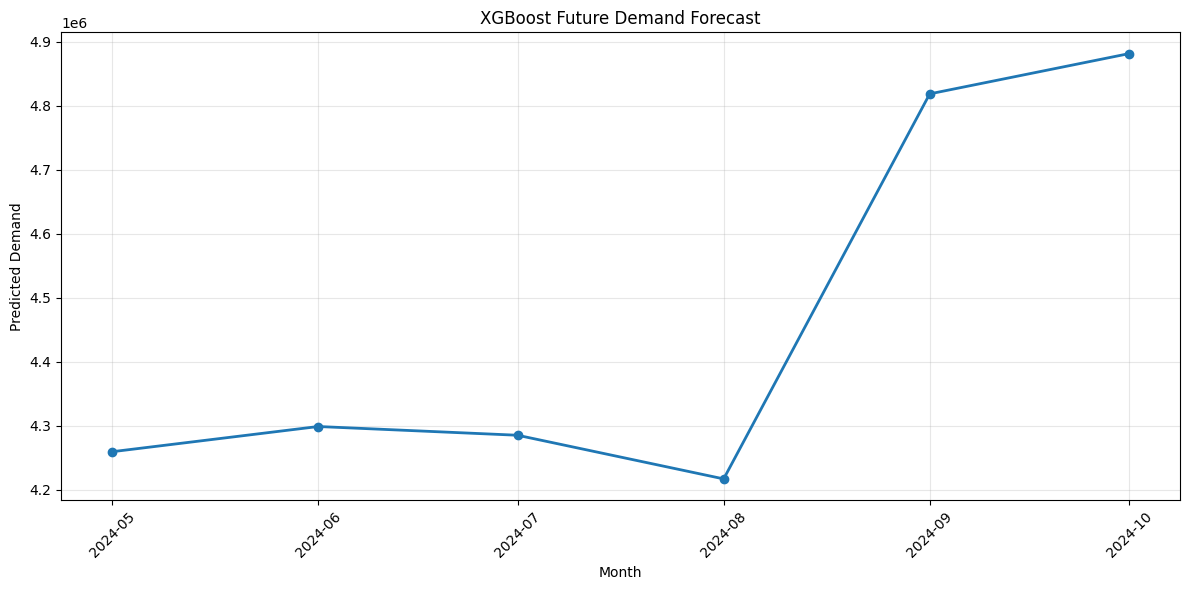

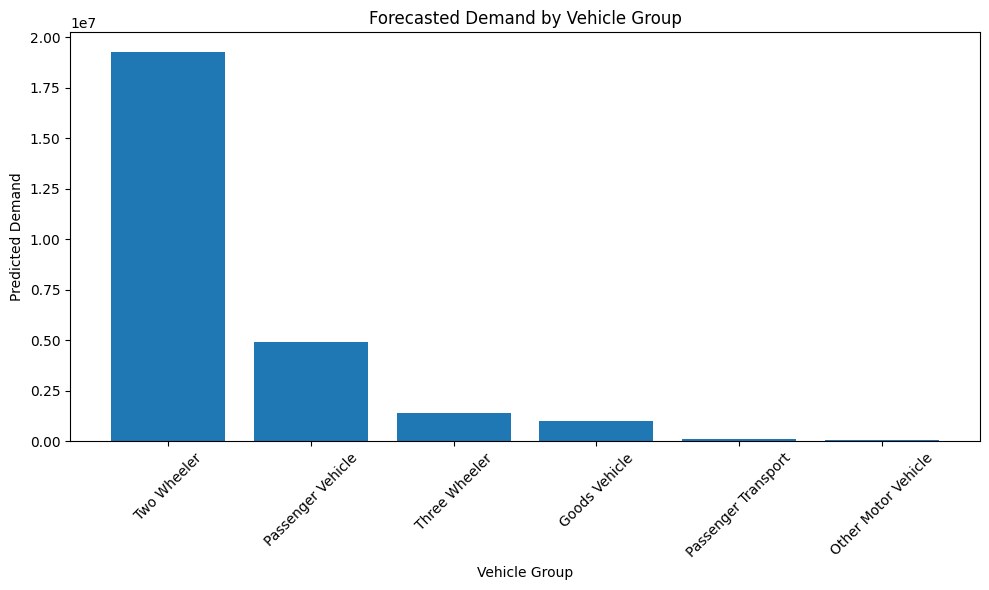

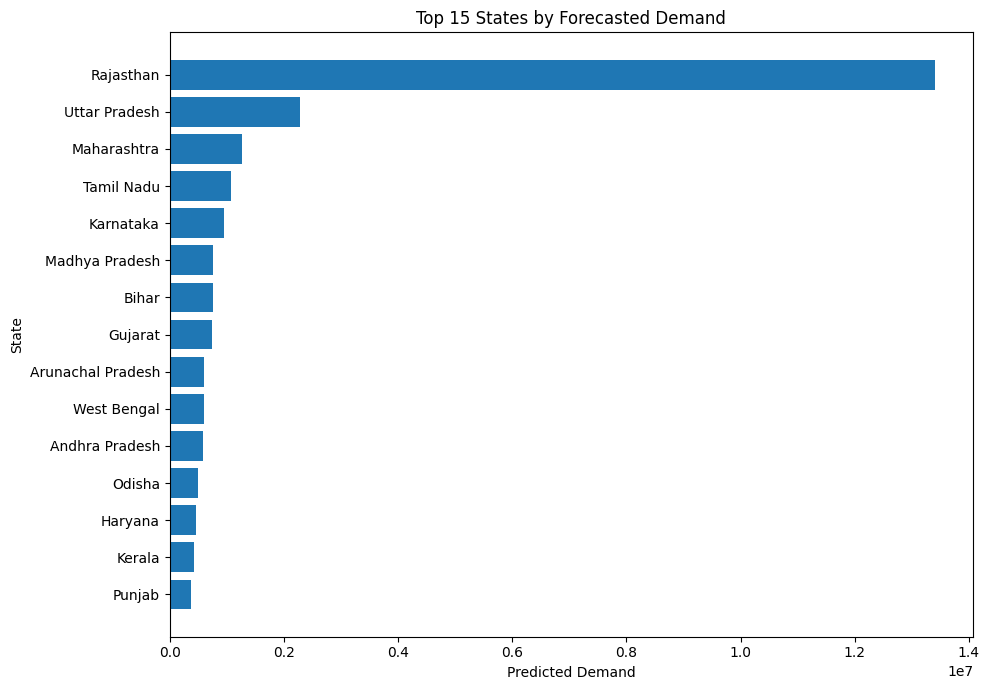

In [86]:
# ============================================================
# FORECAST VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

# Make sure month is datetime
monthly_forecast["month"] = pd.to_datetime(monthly_forecast["month"])

# ------------------------------------------------------------
# 1. MONTHLY DEMAND FORECAST
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast["month"],
    monthly_forecast["predicted_demand"],
    marker="o",
    linewidth=2
)

plt.title("XGBoost Future Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Demand")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 2. VEHICLE GROUP FORECAST
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    vehicle_forecast["vehicle_group"],
    vehicle_forecast["predicted_demand"]
)

plt.title("Forecasted Demand by Vehicle Group")
plt.xlabel("Vehicle Group")
plt.ylabel("Predicted Demand")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 3. TOP 15 STATES
# ------------------------------------------------------------

top_states = state_forecast.head(15).sort_values(
    "predicted_demand"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states["state"],
    top_states["predicted_demand"]
)

plt.title("Top 15 States by Forecasted Demand")
plt.xlabel("Predicted Demand")
plt.ylabel("State")
plt.tight_layout()

plt.show()

In [87]:
# ============================================================
# STATE × VEHICLE GROUP DEMAND ANALYSIS
# ============================================================

print("=" * 70)
print("STATE × VEHICLE GROUP DEMAND ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# TOTAL FORECAST BY STATE × VEHICLE GROUP
# ------------------------------------------------------------

state_vehicle_forecast = (
    forecast_results
    .groupby(
        ["state", "vehicle_group"],
        as_index=False
    )["predicted_demand"]
    .sum()
    .sort_values(
        "predicted_demand",
        ascending=False
    )
)

print("\nState × Vehicle Group forecast shape:")
print(state_vehicle_forecast.shape)

print("\nTop 20 State × Vehicle Group combinations:")
display(
    state_vehicle_forecast.head(20)
)

# ------------------------------------------------------------
# PIVOT TABLE
# ------------------------------------------------------------

state_vehicle_matrix = (
    state_vehicle_forecast
    .pivot(
        index="state",
        columns="vehicle_group",
        values="predicted_demand"
    )
    .fillna(0)
)

print("\nState × Vehicle Group Matrix:")
display(state_vehicle_matrix)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

state_vehicle_forecast.to_csv(
    "state_vehicle_demand_forecast.csv",
    index=False
)

state_vehicle_matrix.to_csv(
    "state_vehicle_demand_matrix.csv"
)

print("\nFiles saved successfully:")
print("✓ state_vehicle_demand_forecast.csv")
print("✓ state_vehicle_demand_matrix.csv")

STATE × VEHICLE GROUP DEMAND ANALYSIS

State × Vehicle Group forecast shape:
(203, 3)

Top 20 State × Vehicle Group combinations:


,state,vehicle_group,predicted_demand
161,Rajasthan,Two Wheeler,9.466148e+06
159,Rajasthan,Passenger Vehicle,2.522722e+06
190,Uttar Pradesh,Two Wheeler,1.737675e+06
113,Maharashtra,Two Wheeler,8.900741e+05
172,Tamil Nadu,Two Wheeler,8.616415e+05
160,Rajasthan,Three Wheeler,7.689758e+05
89,Karnataka,Two Wheeler,6.960286e+05
29,Bihar,Two Wheeler,6.231294e+05
156,Rajasthan,Goods Vehicle,5.816920e+05
107,Madhya Pradesh,Two Wheeler,5.644436e+05



State × Vehicle Group Matrix:


vehicle_group,Goods Vehicle,Other Motor Vehicle,Passenger Transport,Passenger Vehicle,Three Wheeler,Two Wheeler
state,,,,,,
Andaman And Nicobar Islands,2765.824188,1107.865730,7460.235962,2.765824e+03,0.000000,8.415557e+03
Andhra Pradesh,7254.883423,9949.159302,9949.159302,5.640405e+04,44712.001465,4.628309e+05
Arunachal Pradesh,26655.667969,0.000000,3431.389832,5.656314e+04,14525.482666,5.058262e+05
Assam,24246.167725,2765.824188,1651.989410,3.817767e+04,34449.924316,2.384330e+05
Bihar,25929.125488,2765.824188,299.432621,4.697037e+04,56446.230469,6.231294e+05
Chandigarh,2765.824188,1107.865730,7098.590698,6.371894e+03,2765.824188,1.122268e+04
Chhattisgarh,22274.786865,2765.824188,299.432621,5.581280e+04,3792.835815,2.504883e+05
Delhi,3339.081146,1107.865730,299.432621,1.224000e+05,25436.255371,2.110584e+05
Goa,299.432621,1107.865730,3050.173279,3.052225e+03,2765.824188,2.591587e+04



Files saved successfully:
✓ state_vehicle_demand_forecast.csv
✓ state_vehicle_demand_matrix.csv


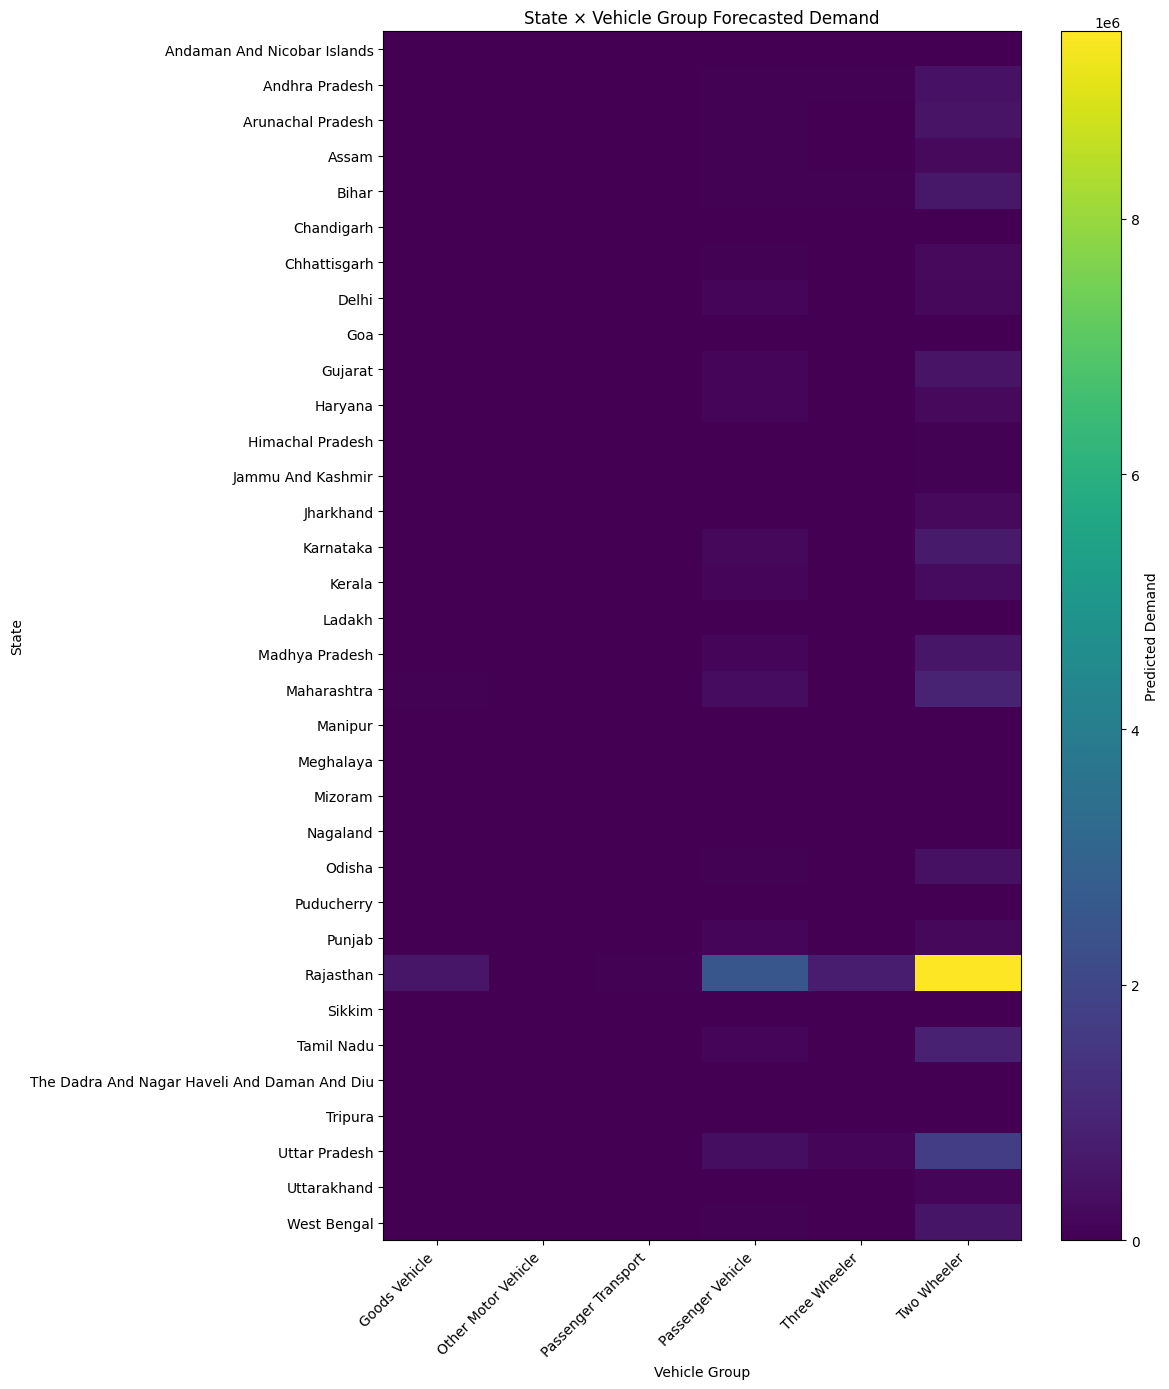

In [88]:
# ============================================================
# STATE × VEHICLE GROUP HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 14))

plt.imshow(
    state_vehicle_matrix.values,
    aspect="auto"
)

plt.colorbar(
    label="Predicted Demand"
)

plt.xticks(
    range(len(state_vehicle_matrix.columns)),
    state_vehicle_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(state_vehicle_matrix.index)),
    state_vehicle_matrix.index
)

plt.title(
    "State × Vehicle Group Forecasted Demand"
)

plt.xlabel("Vehicle Group")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [89]:
# ============================================================
# TOP DEMAND COMBINATIONS
# ============================================================

print("=" * 70)
print("TOP 20 STATE × VEHICLE GROUP DEMAND COMBINATIONS")
print("=" * 70)

top_combinations = (
    state_vehicle_forecast
    .head(20)
    .reset_index(drop=True)
)

display(top_combinations)

TOP 20 STATE × VEHICLE GROUP DEMAND COMBINATIONS


,state,vehicle_group,predicted_demand
0,Rajasthan,Two Wheeler,9.466148e+06
1,Rajasthan,Passenger Vehicle,2.522722e+06
2,Uttar Pradesh,Two Wheeler,1.737675e+06
3,Maharashtra,Two Wheeler,8.900741e+05
4,Tamil Nadu,Two Wheeler,8.616415e+05
5,Rajasthan,Three Wheeler,7.689758e+05
6,Karnataka,Two Wheeler,6.960286e+05
7,Bihar,Two Wheeler,6.231294e+05
8,Rajasthan,Goods Vehicle,5.816920e+05
9,Madhya Pradesh,Two Wheeler,5.644436e+05


In [90]:
# ============================================================
# FINAL FORECAST DATASET
# ============================================================

print("=" * 70)
print("CREATING FINAL FORECAST DATASET")
print("=" * 70)

# Make a clean copy
final_forecast = forecast_results.copy()

# Ensure correct column order
final_forecast = final_forecast[
    [
        "month",
        "state",
        "vehicle_group",
        "predicted_demand"
    ]
]

# Clean values
final_forecast["month"] = pd.to_datetime(final_forecast["month"])

final_forecast["predicted_demand"] = (
    pd.to_numeric(
        final_forecast["predicted_demand"],
        errors="coerce"
    )
    .fillna(0)
    .clip(lower=0)
)

# Sort
final_forecast = final_forecast.sort_values(
    ["month", "state", "vehicle_group"]
).reset_index(drop=True)

# Display information
print("\nFinal dataset shape:")
print(final_forecast.shape)

print("\nColumns:")
print(final_forecast.columns.tolist())

print("\nDate range:")
print(
    final_forecast["month"].min(),
    "to",
    final_forecast["month"].max()
)

print("\nUnique states:")
print(final_forecast["state"].nunique())

print("\nUnique vehicle groups:")
print(final_forecast["vehicle_group"].nunique())

print("\nTotal predicted demand:")
print(
    f"{final_forecast['predicted_demand'].sum():,.2f}"
)

print("\nFirst 20 rows:")
display(final_forecast.head(20))

# ============================================================
# SAVE FINAL DATASET
# ============================================================

final_forecast.to_csv(
    "final_demand_forecast.csv",
    index=False
)

print("\n" + "=" * 70)
print("FINAL FORECAST DATASET SAVED")
print("=" * 70)

print("File: final_demand_forecast.csv")

CREATING FINAL FORECAST DATASET

Final dataset shape:
(1218, 4)

Columns:
['month', 'state', 'vehicle_group', 'predicted_demand']

Date range:
2024-05-01 00:00:00 to 2024-10-01 00:00:00

Unique states:
34

Unique vehicle groups:
6

Total predicted demand:
26,760,503.02

First 20 rows:


,month,state,vehicle_group,predicted_demand
0,2024-05-01,Andaman And Nicobar Islands,Goods Vehicle,369.934143
1,2024-05-01,Andaman And Nicobar Islands,Other Motor Vehicle,93.607948
2,2024-05-01,Andaman And Nicobar Islands,Passenger Transport,1152.336426
3,2024-05-01,Andaman And Nicobar Islands,Passenger Vehicle,369.934143
4,2024-05-01,Andaman And Nicobar Islands,Three Wheeler,0.000000
5,2024-05-01,Andaman And Nicobar Islands,Two Wheeler,1178.827637
6,2024-05-01,Andhra Pradesh,Goods Vehicle,2712.023438
7,2024-05-01,Andhra Pradesh,Other Motor Vehicle,1406.767944
8,2024-05-01,Andhra Pradesh,Passenger Transport,1406.767944
9,2024-05-01,Andhra Pradesh,Passenger Vehicle,8942.592773



FINAL FORECAST DATASET SAVED
File: final_demand_forecast.csv


In [91]:
# ============================================================
# FINAL FORECAST DATA QUALITY CHECK
# ============================================================

print("=" * 70)
print("FINAL FORECAST DATA QUALITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Missing values
# ------------------------------------------------------------

print("\n1. Missing values:")
print(final_forecast.isnull().sum())

# ------------------------------------------------------------
# 2. Duplicate month-state-vehicle combinations
# ------------------------------------------------------------

duplicates = final_forecast.duplicated(
    subset=["month", "state", "vehicle_group"]
).sum()

print("\n2. Duplicate combinations:")
print(duplicates)

# ------------------------------------------------------------
# 3. Negative predictions
# ------------------------------------------------------------

negative_predictions = (
    final_forecast["predicted_demand"] < 0
).sum()

print("\n3. Negative predictions:")
print(negative_predictions)

# ------------------------------------------------------------
# 4. Zero predictions
# ------------------------------------------------------------

zero_predictions = (
    final_forecast["predicted_demand"] == 0
).sum()

print("\n4. Zero predictions:")
print(zero_predictions)

# ------------------------------------------------------------
# 5. Number of unique combinations
# ------------------------------------------------------------

unique_combinations = final_forecast[
    ["month", "state", "vehicle_group"]
].drop_duplicates().shape[0]

print("\n5. Unique month × state × vehicle combinations:")
print(unique_combinations)

# ------------------------------------------------------------
# 6. Expected combinations
# ------------------------------------------------------------

expected_combinations = (
    final_forecast["month"].nunique()
    * final_forecast["state"].nunique()
    * final_forecast["vehicle_group"].nunique()
)

print("\n6. Expected combinations:")
print(expected_combinations)

# ------------------------------------------------------------
# 7. Prediction statistics
# ------------------------------------------------------------

print("\n7. Prediction statistics:")

display(
    final_forecast["predicted_demand"]
    .describe()
    .to_frame()
)

# ------------------------------------------------------------
# 8. Final validation status
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    final_forecast.isnull().sum().sum() == 0
    and duplicates == 0
    and negative_predictions == 0
    and unique_combinations == expected_combinations
):
    print("✅ FINAL FORECAST DATASET PASSED ALL CHECKS")
else:
    print("⚠️ DATASET NEEDS REVIEW")

print("=" * 70)

FINAL FORECAST DATA QUALITY CHECK

1. Missing values:
month               0
state               0
vehicle_group       0
predicted_demand    0
dtype: int64

2. Duplicate combinations:
0

3. Negative predictions:
0

4. Zero predictions:
45

5. Unique month × state × vehicle combinations:
1218

6. Expected combinations:
1224

7. Prediction statistics:


,predicted_demand
count,1.218000e+03
mean,2.197086e+04
std,1.181026e+05
min,0.000000e+00
25%,2.897137e+02
50%,6.607205e+02
75%,5.589135e+03
max,1.774344e+06



⚠️ DATASET NEEDS REVIEW


In [92]:
# ============================================================
# VERIFY STATE × VEHICLE GROUP COMBINATIONS
# ============================================================

print("=" * 70)
print("STATE × VEHICLE GROUP VERIFICATION")
print("=" * 70)

state_vehicle_combinations = (
    final_forecast[
        ["state", "vehicle_group"]
    ]
    .drop_duplicates()
    .sort_values(["state", "vehicle_group"])
)

print("\nActual state × vehicle combinations:")
print(len(state_vehicle_combinations))

print("\nExpected forecast rows:")
print(
    len(state_vehicle_combinations)
    * final_forecast["month"].nunique()
)

print("\nActual forecast rows:")
print(len(final_forecast))

# Find states that do not have all 6 vehicle groups
combination_counts = (
    state_vehicle_combinations
    .groupby("state")["vehicle_group"]
    .nunique()
    .sort_values()
)

print("\nVehicle-group count by state:")
display(combination_counts.to_frame("vehicle_group_count"))

print("\nStates with fewer than 6 vehicle groups:")

display(
    combination_counts[
        combination_counts < 6
    ].to_frame("vehicle_group_count")
)

# Final status
if (
    len(final_forecast)
    == len(state_vehicle_combinations)
    * final_forecast["month"].nunique()
):
    print("\n" + "=" * 70)
    print("✅ FORECAST DATASET STRUCTURE IS CORRECT")
    print("=" * 70)
else:
    print("\n⚠️ STRUCTURE NEEDS REVIEW")

STATE × VEHICLE GROUP VERIFICATION

Actual state × vehicle combinations:
203

Expected forecast rows:
1218

Actual forecast rows:
1218

Vehicle-group count by state:


,vehicle_group_count
state,
Sikkim,5
Andaman And Nicobar Islands,6
Arunachal Pradesh,6
Andhra Pradesh,6
Bihar,6
Chandigarh,6
Chhattisgarh,6
Assam,6
Goa,6



States with fewer than 6 vehicle groups:


,vehicle_group_count
state,
Sikkim,5



✅ FORECAST DATASET STRUCTURE IS CORRECT


In [93]:
# ============================================================
# AUTOSUPPLY-AI — FORECAST ANALYTICS
# ============================================================

print("=" * 70)
print("AUTOSUPPLY-AI FORECAST ANALYTICS")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC KPIs
# ------------------------------------------------------------

total_demand = final_forecast["predicted_demand"].sum()

average_demand = final_forecast["predicted_demand"].mean()

peak_demand = final_forecast["predicted_demand"].max()

peak_row = final_forecast.loc[
    final_forecast["predicted_demand"].idxmax()
]

forecast_months = final_forecast["month"].nunique()

states = final_forecast["state"].nunique()

vehicle_groups = final_forecast["vehicle_group"].nunique()

print("\n" + "=" * 70)
print("KEY FORECAST KPIs")
print("=" * 70)

print(f"\nTotal Forecasted Demand : {total_demand:,.2f}")
print(f"Average Prediction      : {average_demand:,.2f}")
print(f"Peak Predicted Demand   : {peak_demand:,.2f}")
print(f"Forecast Months         : {forecast_months}")
print(f"States                  : {states}")
print(f"Vehicle Groups          : {vehicle_groups}")

print("\nPeak Demand Combination:")
print(f"State          : {peak_row['state']}")
print(f"Vehicle Group  : {peak_row['vehicle_group']}")
print(f"Month          : {peak_row['month']}")
print(f"Demand         : {peak_row['predicted_demand']:,.2f}")


# ------------------------------------------------------------
# 2. MONTHLY FORECAST
# ------------------------------------------------------------

monthly_forecast = (
    final_forecast
    .groupby("month", as_index=False)["predicted_demand"]
    .sum()
    .sort_values("month")
)

monthly_forecast["month"] = pd.to_datetime(
    monthly_forecast["month"]
)

monthly_forecast["month_name"] = (
    monthly_forecast["month"]
    .dt.strftime("%B %Y")
)

print("\n" + "=" * 70)
print("MONTHLY FORECAST")
print("=" * 70)

display(monthly_forecast)


# ------------------------------------------------------------
# 3. VEHICLE GROUP ANALYSIS
# ------------------------------------------------------------

vehicle_analysis = (
    final_forecast
    .groupby("vehicle_group", as_index=False)
    .agg(
        total_demand=("predicted_demand", "sum"),
        average_demand=("predicted_demand", "mean"),
        maximum_demand=("predicted_demand", "max")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
)

vehicle_analysis["demand_share_pct"] = (
    vehicle_analysis["total_demand"]
    / vehicle_analysis["total_demand"].sum()
    * 100
)

print("\n" + "=" * 70)
print("VEHICLE GROUP ANALYSIS")
print("=" * 70)

display(vehicle_analysis)


# ------------------------------------------------------------
# 4. STATE ANALYSIS
# ------------------------------------------------------------

state_analysis = (
    final_forecast
    .groupby("state", as_index=False)
    .agg(
        total_demand=("predicted_demand", "sum"),
        average_demand=("predicted_demand", "mean"),
        maximum_demand=("predicted_demand", "max")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
)

state_analysis["demand_share_pct"] = (
    state_analysis["total_demand"]
    / state_analysis["total_demand"].sum()
    * 100
)

print("\n" + "=" * 70)
print("TOP 20 STATES BY FORECASTED DEMAND")
print("=" * 70)

display(state_analysis.head(20))


# ------------------------------------------------------------
# 5. STATE × VEHICLE GROUP
# ------------------------------------------------------------

state_vehicle_analysis = (
    final_forecast
    .groupby(
        ["state", "vehicle_group"],
        as_index=False
    )
    .agg(
        total_demand=("predicted_demand", "sum"),
        average_demand=("predicted_demand", "mean"),
        maximum_demand=("predicted_demand", "max")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("TOP 20 STATE × VEHICLE GROUP COMBINATIONS")
print("=" * 70)

display(
    state_vehicle_analysis.head(20)
)


# ------------------------------------------------------------
# 6. ZERO-DEMAND FORECASTS
# ------------------------------------------------------------

zero_forecasts = final_forecast[
    final_forecast["predicted_demand"] == 0
].copy()

print("\n" + "=" * 70)
print("ZERO-DEMAND FORECAST CHECK")
print("=" * 70)

print(f"\nZero-demand records: {len(zero_forecasts)}")

if len(zero_forecasts) > 0:
    display(zero_forecasts.head(20))


# ------------------------------------------------------------
# 7. SAVE ANALYTICS TABLES
# ------------------------------------------------------------

monthly_forecast.to_csv(
    "autosupply_monthly_forecast.csv",
    index=False
)

vehicle_analysis.to_csv(
    "autosupply_vehicle_analysis.csv",
    index=False
)

state_analysis.to_csv(
    "autosupply_state_analysis.csv",
    index=False
)

state_vehicle_analysis.to_csv(
    "autosupply_state_vehicle_analysis.csv",
    index=False
)

print("\n" + "=" * 70)
print("✅ FORECAST ANALYTICS CREATED SUCCESSFULLY")
print("=" * 70)

AUTOSUPPLY-AI FORECAST ANALYTICS

KEY FORECAST KPIs

Total Forecasted Demand : 26,760,503.02
Average Prediction      : 21,970.86
Peak Predicted Demand   : 1,774,344.12
Forecast Months         : 6
States                  : 34
Vehicle Groups          : 6

Peak Demand Combination:
State          : Rajasthan
Vehicle Group  : Two Wheeler
Month          : 2024-10-01 00:00:00
Demand         : 1,774,344.12

MONTHLY FORECAST


,month,predicted_demand,month_name
0,2024-05-01,4.259327e+06,May 2024
1,2024-06-01,4.298735e+06,June 2024
2,2024-07-01,4.285073e+06,July 2024
3,2024-08-01,4.216832e+06,August 2024
4,2024-09-01,4.818793e+06,September 2024
5,2024-10-01,4.881743e+06,October 2024



VEHICLE GROUP ANALYSIS


,vehicle_group,total_demand,average_demand,maximum_demand,demand_share_pct
5,Two Wheeler,1.927645e+07,94492.382454,1.774344e+06,72.033198
3,Passenger Vehicle,4.909632e+06,24066.825839,4.312709e+05,18.346563
4,Three Wheeler,1.382957e+06,6984.630875,1.440045e+05,5.167903
0,Goods Vehicle,9.981526e+05,4892.904867,1.083125e+05,3.729947
2,Passenger Transport,1.265953e+05,620.565180,8.443270e+03,0.473068
1,Other Motor Vehicle,6.671972e+04,327.057466,3.093922e+03,0.249322



TOP 20 STATES BY FORECASTED DEMAND


...


TOP 20 STATE × VEHICLE GROUP COMBINATIONS


,state,vehicle_group,total_demand,average_demand,maximum_demand
161,Rajasthan,Two Wheeler,9.466148e+06,1.577691e+06,1.774344e+06
159,Rajasthan,Passenger Vehicle,2.522722e+06,4.204537e+05,4.312709e+05
190,Uttar Pradesh,Two Wheeler,1.737675e+06,2.896124e+05,3.044491e+05
113,Maharashtra,Two Wheeler,8.900741e+05,1.483457e+05,1.668820e+05
172,Tamil Nadu,Two Wheeler,8.616415e+05,1.436069e+05,1.601575e+05
160,Rajasthan,Three Wheeler,7.689758e+05,1.281626e+05,1.440045e+05
89,Karnataka,Two Wheeler,6.960286e+05,1.160048e+05,1.279709e+05
29,Bihar,Two Wheeler,6.231294e+05,1.038549e+05,1.230319e+05
156,Rajasthan,Goods Vehicle,5.816920e+05,9.694867e+04,1.083125e+05
107,Madhya Pradesh,Two Wheeler,5.644436e+05,9.407393e+04,1.105188e+05



ZERO-DEMAND FORECAST CHECK

Zero-demand records: 45


,month,state,vehicle_group,predicted_demand
4,2024-05-01,Andaman And Nicobar Islands,Three Wheeler,0.0
13,2024-05-01,Arunachal Pradesh,Other Motor Vehicle,0.0
26,2024-05-01,Bihar,Passenger Transport,0.0
38,2024-05-01,Chhattisgarh,Passenger Transport,0.0
44,2024-05-01,Delhi,Passenger Transport,0.0
48,2024-05-01,Goa,Goods Vehicle,0.0
55,2024-05-01,Gujarat,Other Motor Vehicle,0.0
56,2024-05-01,Gujarat,Passenger Transport,0.0
73,2024-05-01,Jammu And Kashmir,Other Motor Vehicle,0.0
79,2024-05-01,Jharkhand,Other Motor Vehicle,0.0



✅ FORECAST ANALYTICS CREATED SUCCESSFULLY
